<a href="https://colab.research.google.com/github/pyo-lee/kumc-radiology-ai-workflow-course/blob/main/python_dicom_structure_and_metadata_extraction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 라이브러리 설치
DICOM 이미지 처리와 TCIA API 통신에 필요한 `pydicom`과 `requests` 라이브러리를 설치합니다.

In [1]:
!pip install -q pydicom requests

## 필요한 라이브러리 임포트
데이터 처리, DICOM 파일 읽기, API 요청 및 시각화를 위한 필수 라이브러리들을 임포트합니다.

In [2]:
import os
import zipfile
import requests
import pandas as pd
import pydicom
import matplotlib.pyplot as plt

## TCIA API에서 Series 정보 가져오기
TCIA API를 사용하여 `TCGA-BLCA` 컬렉션에서 `CT` 모달리티를 가진 Series 정보를 가져옵니다. 이 정보는 나중에 DICOM 이미지 다운로드 및 메타데이터 추출에 사용됩니다.

In [3]:
base_url = "https://services.cancerimagingarchive.net/nbia-api/services/v1"

params = {
    "Collection": "TCGA-BLCA",
    "Modality": "CT"
}

response = requests.get(
    f"{base_url}/getSeries",
    params=params
)

series_info = response.json()
series_df = pd.DataFrame(series_info)

series_df.head()

,SeriesInstanceUID,StudyInstanceUID,Modality,ProtocolName,SeriesDate,SeriesDescription,BodyPartExamined,SeriesNumber,Collection,PatientID,...,SoftwareVersions,ImageCount,TimeStamp,LicenseName,LicenseURI,CollectionURI,FileSize,DateReleased,StudyDesc,StudyDate
0,1.3.6.1.4.1.14519.5.2.1.8421.4016.110651529487...,1.3.6.1.4.1.14519.5.2.1.8421.4016.447463489999...,CT,01_Abd_Pelvis,2004-01-20 00:00:00.0,Topogram 0.6 T20s,BLADDER,1,TCGA-BLCA,TCGA-CU-A3QU,...,syngo CT 2007S,2,2014-03-18 08:50:42.0,Creative Commons Attribution 3.0 Unported License,http://creativecommons.org/licenses/by/3.0/,https://doi.org/10.7937/K9/TCIA.2016.8LNG8XDR,1054338,2014-03-18 08:50:42.0,CT ABDOMEN PELVIS W CONT,2004-01-20 00:00:00.0
1,1.3.6.1.4.1.14519.5.2.1.8421.4016.336912504513...,1.3.6.1.4.1.14519.5.2.1.8421.4016.447463489999...,CT,01_Abd_Pelvis,2004-01-20 00:00:00.0,Abd_Pel 5.0 B31f,BLADDER,2,TCGA-BLCA,TCGA-CU-A3QU,...,syngo CT 2007S,103,2014-03-18 08:51:26.0,Creative Commons Attribution 3.0 Unported License,http://creativecommons.org/licenses/by/3.0/,https://doi.org/10.7937/K9/TCIA.2016.8LNG8XDR,54303984,2014-03-18 08:51:26.0,CT ABDOMEN PELVIS W CONT,2004-01-20 00:00:00.0
2,1.3.6.1.4.1.14519.5.2.1.8421.4016.117955287151...,1.3.6.1.4.1.14519.5.2.1.8421.4016.457123040069...,CT,01_Abd_Pelvis,2003-12-30 00:00:00.0,Topogram 0.6 T20s,BLADDER,1,TCGA-BLCA,TCGA-CU-A3KJ,...,syngo CT 2007S,2,2014-03-18 08:51:26.0,Creative Commons Attribution 3.0 Unported License,http://creativecommons.org/licenses/by/3.0/,https://doi.org/10.7937/K9/TCIA.2016.8LNG8XDR,1054274,2014-03-18 08:51:26.0,CT ABDOMEN PELVIS W CONT,2003-12-30 00:00:00.0
3,1.3.6.1.4.1.14519.5.2.1.8421.4016.249239037299...,1.3.6.1.4.1.14519.5.2.1.8421.4016.457123040069...,CT,01_Abd_Pelvis,2003-12-30 00:00:00.0,Abd_Pel 5.0 B31f,BLADDER,2,TCGA-BLCA,TCGA-CU-A3KJ,...,syngo CT 2007S,96,2014-03-18 08:52:07.0,Creative Commons Attribution 3.0 Unported License,http://creativecommons.org/licenses/by/3.0/,https://doi.org/10.7937/K9/TCIA.2016.8LNG8XDR,50616814,2014-03-18 08:52:07.0,CT ABDOMEN PELVIS W CONT,2003-12-30 00:00:00.0
4,1.3.6.1.4.1.14519.5.2.1.8421.4016.126220627862...,1.3.6.1.4.1.14519.5.2.1.8421.4016.541431505654...,CT,01_Abd_Pelvis,2002-08-16 00:00:00.0,Topogram 0.6 T20s,BLADDER,1,TCGA-BLCA,TCGA-CU-A0YR,...,syngo CT 2007S,2,2014-03-18 08:52:07.0,Creative Commons Attribution 3.0 Unported License,http://creativecommons.org/licenses/by/3.0/,https://doi.org/10.7937/K9/TCIA.2016.8LNG8XDR,1054358,2014-03-18 08:52:07.0,CT ABDOMEN PELVIS W CONT,2002-08-16 00:00:00.0


## Series 정보 요약 확인
가져온 Series 정보 DataFrame(`series_df`)에서 환자 ID, 모달리티, 신체 부위, Series 설명, 이미지 수, SeriesInstanceUID 등의 주요 컬럼을 확인합니다.

In [4]:
series_df[["PatientID", "Modality", "BodyPartExamined", "SeriesDescription", "ImageCount", "SeriesInstanceUID"]].head()

,PatientID,Modality,BodyPartExamined,SeriesDescription,ImageCount,SeriesInstanceUID
0,TCGA-CU-A3QU,CT,BLADDER,Topogram 0.6 T20s,2,1.3.6.1.4.1.14519.5.2.1.8421.4016.110651529487...
1,TCGA-CU-A3QU,CT,BLADDER,Abd_Pel 5.0 B31f,103,1.3.6.1.4.1.14519.5.2.1.8421.4016.336912504513...
2,TCGA-CU-A3KJ,CT,BLADDER,Topogram 0.6 T20s,2,1.3.6.1.4.1.14519.5.2.1.8421.4016.117955287151...
3,TCGA-CU-A3KJ,CT,BLADDER,Abd_Pel 5.0 B31f,96,1.3.6.1.4.1.14519.5.2.1.8421.4016.249239037299...
4,TCGA-CU-A0YR,CT,BLADDER,Topogram 0.6 T20s,2,1.3.6.1.4.1.14519.5.2.1.8421.4016.126220627862...


## 이미지 수가 가장 적은 Series 선택
DICOM 데이터 다운로드 및 처리를 위해 `ImageCount`가 가장 작은 하나의 Series를 선택합니다.

In [5]:
# 이미지 수가 적은 series 하나 선택
small_series = series_df.sort_values("ImageCount").iloc[0]
small_series


,27
SeriesInstanceUID,1.3.6.1.4.1.14519.5.2.1.8421.4016.286439195792...
StudyInstanceUID,1.3.6.1.4.1.14519.5.2.1.8421.4016.115811788122...
Modality,CT
ProtocolName,ROUTINE_ABD_PELVIS_Customized
SeriesDate,2003-11-13 00:00:00.0
SeriesDescription,Topogram 0.6 T20s
BodyPartExamined,BLADDER
SeriesNumber,1
Collection,TCGA-BLCA
PatientID,TCGA-CU-A3QU


## 선택된 Series 정보 출력
선택된 Series의 `SeriesInstanceUID`와 `ImageCount`를 출력하여 확인합니다.

In [6]:
series_uid = small_series["SeriesInstanceUID"]

print("Selected SeriesInstanceUID:", series_uid)
print("ImageCount:", small_series["ImageCount"])

Selected SeriesInstanceUID: 1.3.6.1.4.1.14519.5.2.1.8421.4016.286439195792855747814564781819
ImageCount: 1


## DICOM 파일 다운로드 및 압축 해제 함수 정의 및 실행
선택한 Series의 DICOM 파일을 TCIA API로부터 다운로드하고 압축을 해제하는 유틸리티 함수(`download_zip_file`, `unzip_file`)를 정의하고 실행합니다.

In [7]:

def download_zip_file(base_url, series_uid, zip_path):
  response = requests.get(
      f"{base_url}/getImage",
      params={"SeriesInstanceUID": series_uid},
      stream=True
  )

  with open(zip_path, "wb") as f:
      for chunk in response.iter_content(chunk_size=8192):
          if chunk:
              f.write(chunk)

  print("Downloaded:", zip_path)

def unzip_file(zip_path, download_dir):
  with zipfile.ZipFile(zip_path, "r") as zip_ref:
      zip_ref.extractall(download_dir)

  print("Unzipped:", zip_path)

download_dir = "/content/tcia_dicom"
zip_path = "/content/tcia_series.zip"

os.makedirs(download_dir, exist_ok=True)

download_zip_file(base_url, series_uid, zip_path)
unzip_file(zip_path, download_dir)


Downloaded: /content/tcia_series.zip
Unzipped: /content/tcia_series.zip


## 다운로드된 DICOM 파일 목록 확인
다운로드 및 압축 해제된 디렉토리에서 실제로 DICOM 파일들을 찾아 목록을 생성하고, 파일의 개수를 확인합니다.

In [8]:
dicom_files = []

for root, dirs, files in os.walk(download_dir):
    for file in files:
        file_path = os.path.join(root, file)
        try:
            ds = pydicom.dcmread(file_path, stop_before_pixels=True)
            dicom_files.append(file_path)
        except:
            pass

print("Number of DICOM files:", len(dicom_files))
dicom_files[:5]

Number of DICOM files: 37


['/content/tcia_dicom/00000015.dcm',
 '/content/tcia_dicom/00000020.dcm',
 '/content/tcia_dicom/00000012.dcm',
 '/content/tcia_dicom/00000036.dcm',
 '/content/tcia_dicom/00000013.dcm']

## 샘플 DICOM 파일 메타데이터 확인
다운로드된 DICOM 파일 중 첫 번째 파일(`dicom_files[0]`)을 읽어와 주요 메타데이터(PatientID, Modality, StudyDescription 등)를 출력합니다.

In [9]:
ds = pydicom.dcmread(dicom_files[0])

print("PatientID:", ds.get("PatientID", "N/A"))
print("Modality:", ds.get("Modality", "N/A"))
print("StudyDescription:", ds.get("StudyDescription", "N/A"))
print("SeriesDescription:", ds.get("SeriesDescription", "N/A"))
print("Rows:", ds.get("Rows", "N/A"))
print("Columns:", ds.get("Columns", "N/A"))

PatientID: TCGA-FD-A3SP
Modality: CT
StudyDescription: Abdomen^UROGRAM (Adult)
SeriesDescription: VRT IMAGES
Rows: 512
Columns: 512


## DICOM 이미지 시각화
샘플 DICOM 파일의 픽셀 데이터를 `matplotlib`을 이용하여 흑백 이미지로 시각화합니다.

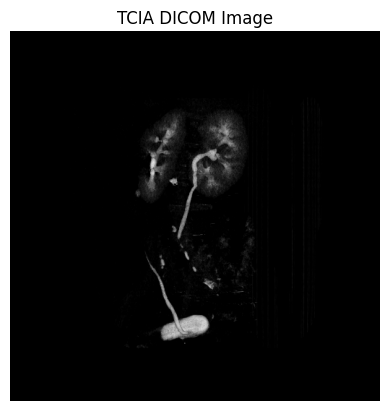

In [10]:
plt.imshow(ds.pixel_array, cmap="gray")
plt.title("TCIA DICOM Image")
plt.axis("off")
plt.show()

## 추가 라이브러리 임포트
이후 다중 환자 DICOM 데이터 처리 및 분석을 위해 `tqdm` 라이브러리를 추가로 임포트합니다.

In [11]:
import os
import zipfile
import requests
import pandas as pd
import pydicom
from tqdm import tqdm

## 다중 환자 Series 정보 가져오기 및 처리 준비
TCIA API를 사용하여 `TCGA-KIRC` 컬렉션의 Series 정보를 가져옵니다. `safe_get_json` 함수를 통해 API 요청의 안정성을 높이고, 가져온 데이터를 DataFrame으로 변환하여 추가 처리 준비를 합니다.

In [12]:
base_url = "https://services.cancerimagingarchive.net/nbia-api/services/v1"

# 사용할 공개 DICOM collection
collection = "TCGA-KIRC"

def safe_get_json(endpoint, params=None):
    response = requests.get(
        f"{base_url}/{endpoint}",
        params=params,
        timeout=60
    )

    print("Request URL:", response.url)
    print("Status code:", response.status_code)

    if response.status_code != 200:
        print(response.text[:500])
        raise RuntimeError(f"API request failed: {response.status_code}")

    return response.json()


series_json = safe_get_json(
    "getSeries",
    params={"Collection": collection}
)

series_df = pd.DataFrame(series_json)

print(series_df.shape)
series_df.head()

Request URL: https://services.cancerimagingarchive.net/nbia-api/services/v1/getSeries?Collection=TCGA-KIRC
Status code: 200
(2654, 22)


,SeriesInstanceUID,StudyInstanceUID,Modality,SeriesDate,SeriesDescription,BodyPartExamined,SeriesNumber,Collection,PatientID,Manufacturer,...,ImageCount,TimeStamp,LicenseName,LicenseURI,CollectionURI,FileSize,DateReleased,StudyDesc,StudyDate,ProtocolName
0,1.3.6.1.4.1.14519.5.2.1.9203.4004.652695091345...,1.3.6.1.4.1.14519.5.2.1.9203.4004.105518938583...,MR,1987-01-13 00:00:00.0,Localizer,KIDNEY,2,TCGA-KIRC,TCGA-BP-4170,GE MEDICAL SYSTEMS,...,15,2012-08-01 11:20:27.0,Creative Commons Attribution 3.0 Unported License,http://creativecommons.org/licenses/by/3.0/,https://doi.org/10.7937/K9/TCIA.2016.V6PBVTDR,2049826,2012-08-01 11:20:27.0,MR ABDOMEN W/WO CONTRAST,1987-01-13 00:00:00.0,NaN
1,1.3.6.1.4.1.14519.5.2.1.9203.4004.291572847801...,1.3.6.1.4.1.14519.5.2.1.9203.4004.105518938583...,MR,1987-01-13 00:00:00.0,Axial in/out phase,KIDNEY,6,TCGA-KIRC,TCGA-BP-4170,GE MEDICAL SYSTEMS,...,48,2012-08-01 11:20:39.0,Creative Commons Attribution 3.0 Unported License,http://creativecommons.org/licenses/by/3.0/,https://doi.org/10.7937/K9/TCIA.2016.V6PBVTDR,6560536,2012-08-01 11:20:39.0,MR ABDOMEN W/WO CONTRAST,1987-01-13 00:00:00.0,NaN
2,1.3.6.1.4.1.14519.5.2.1.9203.4004.223793480341...,1.3.6.1.4.1.14519.5.2.1.9203.4004.105518938583...,MR,1987-01-13 00:00:00.0,Axial MRCP thin,KIDNEY,4,TCGA-KIRC,TCGA-BP-4170,GE MEDICAL SYSTEMS,...,20,2012-08-01 11:20:44.0,Creative Commons Attribution 3.0 Unported License,http://creativecommons.org/licenses/by/3.0/,https://doi.org/10.7937/K9/TCIA.2016.V6PBVTDR,2733760,2012-08-01 11:20:44.0,MR ABDOMEN W/WO CONTRAST,1987-01-13 00:00:00.0,NaN
3,1.3.6.1.4.1.14519.5.2.1.9203.4004.337629194550...,1.3.6.1.4.1.14519.5.2.1.9203.4004.105518938583...,MR,1987-01-13 00:00:00.0,Axial T2 fat sat,KIDNEY,5,TCGA-KIRC,TCGA-BP-4170,GE MEDICAL SYSTEMS,...,24,2012-08-01 11:20:50.0,Creative Commons Attribution 3.0 Unported License,http://creativecommons.org/licenses/by/3.0/,https://doi.org/10.7937/K9/TCIA.2016.V6PBVTDR,3280796,2012-08-01 11:20:50.0,MR ABDOMEN W/WO CONTRAST,1987-01-13 00:00:00.0,NaN
4,1.3.6.1.4.1.14519.5.2.1.9203.4004.117955257640...,1.3.6.1.4.1.14519.5.2.1.9203.4004.105518938583...,MR,1987-01-13 00:00:00.0,Axial flow sensitive post,KIDNEY,8,TCGA-KIRC,TCGA-BP-4170,GE MEDICAL SYSTEMS,...,40,2012-08-01 11:20:57.0,Creative Commons Attribution 3.0 Unported License,http://creativecommons.org/licenses/by/3.0/,https://doi.org/10.7937/K9/TCIA.2016.V6PBVTDR,5467432,2012-08-01 11:20:57.0,MR ABDOMEN W/WO CONTRAST,1987-01-13 00:00:00.0,NaN


## 환자별 DICOM Series 선택 및 필터링
가져온 Series DataFrame에서 `ImageCount`를 숫자로 변환하고, 유효한 Series만 필터링합니다. 각 환자별로 `ImageCount`가 가장 작은 하나의 Series를 선택하여 `selected_series_df`를 생성합니다. 이는 분석 대상 데이터를 효율적으로 관리하기 위함입니다.

In [13]:
# ImageCount를 숫자로 변환
series_df["ImageCount"] = pd.to_numeric(series_df["ImageCount"], errors="coerce")

# ImageCount가 있는 series만 사용
series_df_valid = series_df.dropna(subset=["PatientID", "SeriesInstanceUID", "ImageCount"]).copy()

# 너무 큰 series는 제외하고 싶으면 아래 조건 사용 가능
# series_df_valid = series_df_valid[series_df_valid["ImageCount"] <= 100]

# 환자별로 ImageCount가 가장 작은 series 1개 선택
selected_series_df = (
    series_df_valid
    .sort_values(["PatientID", "ImageCount"])
    .drop_duplicates(subset=["PatientID"], keep="first")
    .head(10)
    .reset_index(drop=True)
)

selected_series_df[
    ["PatientID", "Modality", "BodyPartExamined", "SeriesDescription", "ImageCount", "SeriesInstanceUID"]
]

,PatientID,Modality,BodyPartExamined,SeriesDescription,ImageCount,SeriesInstanceUID
0,TCGA-B0-4698,CT,KIDNEY,SCOUT AP/LAT,2,1.3.6.1.4.1.14519.5.2.1.6450.4004.210570060627...
1,TCGA-B0-4712,CT,KIDNEY,SCOUT,2,1.3.6.1.4.1.14519.5.2.1.6450.4004.919148974051...
2,TCGA-B0-4713,CT,KIDNEY,NaN,2,1.3.6.1.4.1.14519.5.2.1.6450.4004.185347454720...
3,TCGA-B0-4821,CT,KIDNEY,NaN,1,1.3.6.1.4.1.14519.5.2.1.6450.4004.235428597036...
4,TCGA-B0-4833,CT,KIDNEY,SCOUT AP/LAT,2,1.3.6.1.4.1.14519.5.2.1.6450.4004.124815748260...
5,TCGA-B0-4839,CT,KIDNEY,SCOUT,2,1.3.6.1.4.1.14519.5.2.1.6450.4004.201946170668...
6,TCGA-B0-4843,CT,KIDNEY,NaN,2,1.3.6.1.4.1.14519.5.2.1.6450.4004.129128653040...
7,TCGA-B0-4845,CT,KIDNEY,NaN,2,1.3.6.1.4.1.14519.5.2.1.6450.4004.396309753165...
8,TCGA-B0-4849,MR,KIDNEY,PJN,11,1.3.6.1.4.1.14519.5.2.1.6450.4004.234542686322...
9,TCGA-B0-5077,CT,KIDNEY,NaN,2,1.3.6.1.4.1.14519.5.2.1.6450.4004.116101561736...


## 다중 환자 DICOM Series 다운로드 함수 정의
여러 환자의 DICOM Series를 다운로드하고 압축을 해제하는 `download_series` 함수를 정의합니다. 이 함수는 각 환자의 DICOM 데이터를 지정된 디렉토리에 저장합니다.

In [14]:
download_root = "/content/tcia_multi_patient_dicom"
os.makedirs(download_root, exist_ok=True)

def download_series(series_uid, patient_id, output_root):
    patient_dir = os.path.join(output_root, str(patient_id))
    os.makedirs(patient_dir, exist_ok=True)

    zip_path = os.path.join(patient_dir, f"{series_uid}.zip")
    extract_dir = os.path.join(patient_dir, "dicom")
    os.makedirs(extract_dir, exist_ok=True)

    # 이미 압축 해제된 파일이 있으면 재다운로드 생략
    if len(os.listdir(extract_dir)) > 0:
        return extract_dir

    response = requests.get(
        f"{base_url}/getImage",
        params={"SeriesInstanceUID": series_uid},
        stream=True,
        timeout=120
    )

    if response.status_code != 200:
        print("Download failed:", patient_id, series_uid, response.status_code)
        return None

    with open(zip_path, "wb") as f:
        for chunk in response.iter_content(chunk_size=8192):
            if chunk:
                f.write(chunk)

    if not zipfile.is_zipfile(zip_path):
        print("Downloaded file is not a zip:", zip_path)
        return None

    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extract_dir)

    return extract_dir

## 선택된 Series 일괄 다운로드
`selected_series_df`에 있는 각 Series에 대해 `download_series` 함수를 호출하여 DICOM 데이터를 일괄적으로 다운로드하고, 다운로드된 정보(`downloaded_df`)를 DataFrame으로 저장합니다.

In [15]:
downloaded_info = []

for _, row in tqdm(selected_series_df.iterrows(), total=len(selected_series_df)):
    patient_id = row["PatientID"]
    series_uid = row["SeriesInstanceUID"]

    extract_dir = download_series(
        series_uid=series_uid,
        patient_id=patient_id,
        output_root=download_root
    )

    downloaded_info.append({
        "PatientID": patient_id,
        "SeriesInstanceUID": series_uid,
        "extract_dir": extract_dir
    })

downloaded_df = pd.DataFrame(downloaded_info)
downloaded_df

100%|██████████| 10/10 [00:00<00:00, 2674.94it/s]


,PatientID,SeriesInstanceUID,extract_dir
0,TCGA-B0-4698,1.3.6.1.4.1.14519.5.2.1.6450.4004.210570060627...,/content/tcia_multi_patient_dicom/TCGA-B0-4698...
1,TCGA-B0-4712,1.3.6.1.4.1.14519.5.2.1.6450.4004.919148974051...,/content/tcia_multi_patient_dicom/TCGA-B0-4712...
2,TCGA-B0-4713,1.3.6.1.4.1.14519.5.2.1.6450.4004.185347454720...,/content/tcia_multi_patient_dicom/TCGA-B0-4713...
3,TCGA-B0-4821,1.3.6.1.4.1.14519.5.2.1.6450.4004.235428597036...,/content/tcia_multi_patient_dicom/TCGA-B0-4821...
4,TCGA-B0-4833,1.3.6.1.4.1.14519.5.2.1.6450.4004.124815748260...,/content/tcia_multi_patient_dicom/TCGA-B0-4833...
5,TCGA-B0-4839,1.3.6.1.4.1.14519.5.2.1.6450.4004.201946170668...,/content/tcia_multi_patient_dicom/TCGA-B0-4839...
6,TCGA-B0-4843,1.3.6.1.4.1.14519.5.2.1.6450.4004.129128653040...,/content/tcia_multi_patient_dicom/TCGA-B0-4843...
7,TCGA-B0-4845,1.3.6.1.4.1.14519.5.2.1.6450.4004.396309753165...,/content/tcia_multi_patient_dicom/TCGA-B0-4845...
8,TCGA-B0-4849,1.3.6.1.4.1.14519.5.2.1.6450.4004.234542686322...,/content/tcia_multi_patient_dicom/TCGA-B0-4849...
9,TCGA-B0-5077,1.3.6.1.4.1.14519.5.2.1.6450.4004.116101561736...,/content/tcia_multi_patient_dicom/TCGA-B0-5077...


## 다운로드된 DICOM 파일 경로 추출
다운로드된 각 Series의 디렉토리에서 첫 번째 DICOM 파일의 경로를 찾는 `find_first_dicom_file` 함수를 정의하고, `downloaded_df`에 이 경로를 추가합니다.

In [16]:
def find_first_dicom_file(folder_path):
    if folder_path is None:
        return None

    for root, dirs, files in os.walk(folder_path):
        for file in files:
            file_path = os.path.join(root, file)

            try:
                # header만 읽어서 DICOM인지 확인
                _ = pydicom.dcmread(file_path, stop_before_pixels=True)
                return file_path
            except:
                continue

    return None


downloaded_df["sample_dicom_path"] = downloaded_df["extract_dir"].apply(find_first_dicom_file)

downloaded_df

,PatientID,SeriesInstanceUID,extract_dir,sample_dicom_path
0,TCGA-B0-4698,1.3.6.1.4.1.14519.5.2.1.6450.4004.210570060627...,/content/tcia_multi_patient_dicom/TCGA-B0-4698...,/content/tcia_multi_patient_dicom/TCGA-B0-4698...
1,TCGA-B0-4712,1.3.6.1.4.1.14519.5.2.1.6450.4004.919148974051...,/content/tcia_multi_patient_dicom/TCGA-B0-4712...,/content/tcia_multi_patient_dicom/TCGA-B0-4712...
2,TCGA-B0-4713,1.3.6.1.4.1.14519.5.2.1.6450.4004.185347454720...,/content/tcia_multi_patient_dicom/TCGA-B0-4713...,/content/tcia_multi_patient_dicom/TCGA-B0-4713...
3,TCGA-B0-4821,1.3.6.1.4.1.14519.5.2.1.6450.4004.235428597036...,/content/tcia_multi_patient_dicom/TCGA-B0-4821...,/content/tcia_multi_patient_dicom/TCGA-B0-4821...
4,TCGA-B0-4833,1.3.6.1.4.1.14519.5.2.1.6450.4004.124815748260...,/content/tcia_multi_patient_dicom/TCGA-B0-4833...,/content/tcia_multi_patient_dicom/TCGA-B0-4833...
5,TCGA-B0-4839,1.3.6.1.4.1.14519.5.2.1.6450.4004.201946170668...,/content/tcia_multi_patient_dicom/TCGA-B0-4839...,/content/tcia_multi_patient_dicom/TCGA-B0-4839...
6,TCGA-B0-4843,1.3.6.1.4.1.14519.5.2.1.6450.4004.129128653040...,/content/tcia_multi_patient_dicom/TCGA-B0-4843...,/content/tcia_multi_patient_dicom/TCGA-B0-4843...
7,TCGA-B0-4845,1.3.6.1.4.1.14519.5.2.1.6450.4004.396309753165...,/content/tcia_multi_patient_dicom/TCGA-B0-4845...,/content/tcia_multi_patient_dicom/TCGA-B0-4845...
8,TCGA-B0-4849,1.3.6.1.4.1.14519.5.2.1.6450.4004.234542686322...,/content/tcia_multi_patient_dicom/TCGA-B0-4849...,/content/tcia_multi_patient_dicom/TCGA-B0-4849...
9,TCGA-B0-5077,1.3.6.1.4.1.14519.5.2.1.6450.4004.116101561736...,/content/tcia_multi_patient_dicom/TCGA-B0-5077...,/content/tcia_multi_patient_dicom/TCGA-B0-5077...


## DICOM 메타데이터 추출 함수 정의
주어진 DICOM 파일 경로에서 다양한 메타데이터 태그를 추출하는 `extract_one_dicom_metadata` 함수와 픽셀 간격을 포맷팅하는 `format_pixel_spacing` 함수를 정의합니다.

In [17]:
def get_dicom_value(ds, tag_name, default=None):
    return getattr(ds, tag_name, default)


def format_pixel_spacing(pixel_spacing):
    if pixel_spacing is None:
        return None

    try:
        return " x ".join([str(float(x)) for x in pixel_spacing])
    except:
        return str(pixel_spacing)


def extract_one_dicom_metadata(file_path):
    if file_path is None:
        return {
            "sample_dicom_path": None,
            "error": "No DICOM file found"
        }

    try:
        ds = pydicom.dcmread(file_path, stop_before_pixels=True, force=True)

        metadata = {
            "sample_dicom_path": file_path,

            # Patient-level
            "PatientID": get_dicom_value(ds, "PatientID"),
            "PatientSex": get_dicom_value(ds, "PatientSex"),
            "PatientAge": get_dicom_value(ds, "PatientAge"),

            # Study-level
            "StudyInstanceUID": get_dicom_value(ds, "StudyInstanceUID"),
            "StudyDate": get_dicom_value(ds, "StudyDate"),
            "StudyDescription": get_dicom_value(ds, "StudyDescription"),

            # Series-level
            "SeriesInstanceUID": get_dicom_value(ds, "SeriesInstanceUID"),
            "SeriesDate": get_dicom_value(ds, "SeriesDate"),
            "SeriesDescription": get_dicom_value(ds, "SeriesDescription"),
            "SeriesNumber": get_dicom_value(ds, "SeriesNumber"),

            # Imaging information
            "Modality": get_dicom_value(ds, "Modality"),
            "BodyPartExamined": get_dicom_value(ds, "BodyPartExamined"),
            "ProtocolName": get_dicom_value(ds, "ProtocolName"),

            # Scanner information
            "Manufacturer": get_dicom_value(ds, "Manufacturer"),
            "ManufacturerModelName": get_dicom_value(ds, "ManufacturerModelName"),
            "MagneticFieldStrength": get_dicom_value(ds, "MagneticFieldStrength"),

            # Image geometry
            "Rows": get_dicom_value(ds, "Rows"),
            "Columns": get_dicom_value(ds, "Columns"),
            "SliceThickness": get_dicom_value(ds, "SliceThickness"),
            "SpacingBetweenSlices": get_dicom_value(ds, "SpacingBetweenSlices"),
            "PixelSpacing": format_pixel_spacing(get_dicom_value(ds, "PixelSpacing")),

            # Instance-level
            "InstanceNumber": get_dicom_value(ds, "InstanceNumber"),

            "error": None
        }

        return metadata

    except Exception as e:
        return {
            "sample_dicom_path": file_path,
            "error": str(e)
        }

## 추출된 DICOM 메타데이터 통합
`downloaded_df`의 각 Series에서 샘플 DICOM 파일의 메타데이터를 추출하고, API에서 가져온 정보와 결합하여 `patient_dicom_metadata_df` DataFrame을 생성합니다.

In [18]:
metadata_list = []

for _, row in tqdm(downloaded_df.iterrows(), total=len(downloaded_df)):
    metadata = extract_one_dicom_metadata(row["sample_dicom_path"])

    # API에서 가져온 정보도 같이 추가
    metadata["Collection"] = collection
    metadata["API_PatientID"] = row["PatientID"]
    metadata["API_SeriesInstanceUID"] = row["SeriesInstanceUID"]

    metadata_list.append(metadata)

patient_dicom_metadata_df = pd.DataFrame(metadata_list)

patient_dicom_metadata_df

100%|██████████| 10/10 [00:00<00:00, 233.72it/s]


,sample_dicom_path,PatientID,PatientSex,PatientAge,StudyInstanceUID,StudyDate,StudyDescription,SeriesInstanceUID,SeriesDate,SeriesDescription,...,Rows,Columns,SliceThickness,SpacingBetweenSlices,PixelSpacing,InstanceNumber,error,Collection,API_PatientID,API_SeriesInstanceUID
0,/content/tcia_multi_patient_dicom/TCGA-B0-4698...,TCGA-B0-4698,M,075Y,1.3.6.1.4.1.14519.5.2.1.6450.4004.232784766874...,19851122,CT ABDOMEN,1.3.6.1.4.1.14519.5.2.1.6450.4004.210570060627...,19851122,SCOUT AP/LAT,...,1027,888,560.181824,NaN,0.545455 x 0.596847,1,None,TCGA-KIRC,TCGA-B0-4698,1.3.6.1.4.1.14519.5.2.1.6450.4004.210570060627...
1,/content/tcia_multi_patient_dicom/TCGA-B0-4712...,TCGA-B0-4712,M,079Y,1.3.6.1.4.1.14519.5.2.1.6450.4004.210523491495...,19920505,CT ABDOMEN WITH CONTRA,1.3.6.1.4.1.14519.5.2.1.6450.4004.919148974051...,19920505,SCOUT,...,1283,888,700.090881,NaN,0.545455 x 0.596847,1,None,TCGA-KIRC,TCGA-B0-4712,1.3.6.1.4.1.14519.5.2.1.6450.4004.919148974051...
2,/content/tcia_multi_patient_dicom/TCGA-B0-4713...,TCGA-B0-4713,F,076Y,1.3.6.1.4.1.14519.5.2.1.6450.4004.267828530238...,19920622,ct a/p w/wo,1.3.6.1.4.1.14519.5.2.1.6450.4004.185347454720...,19920622,,...,1155,888,630.181824,NaN,0.545455 x 0.596847,1,None,TCGA-KIRC,TCGA-B0-4713,1.3.6.1.4.1.14519.5.2.1.6450.4004.185347454720...
3,/content/tcia_multi_patient_dicom/TCGA-B0-4821...,TCGA-B0-4821,F,068Y,1.3.6.1.4.1.14519.5.2.1.6450.4004.106932788840...,19841028,ABDOMEN W/WO,1.3.6.1.4.1.14519.5.2.1.6450.4004.235428597036...,19841028,,...,1100,888,600.181824,NaN,0.545455 x 0.596847,1,None,TCGA-KIRC,TCGA-B0-4821,1.3.6.1.4.1.14519.5.2.1.6450.4004.235428597036...
4,/content/tcia_multi_patient_dicom/TCGA-B0-4833...,TCGA-B0-4833,F,082Y,1.3.6.1.4.1.14519.5.2.1.6450.4004.131965569276...,19850628,CT ABD/PEL,1.3.6.1.4.1.14519.5.2.1.6450.4004.124815748260...,19850628,SCOUT AP/LAT,...,1027,888,560.181824,NaN,0.545455 x 0.596847,1,None,TCGA-KIRC,TCGA-B0-4833,1.3.6.1.4.1.14519.5.2.1.6450.4004.124815748260...
5,/content/tcia_multi_patient_dicom/TCGA-B0-4839...,TCGA-B0-4839,F,080Y,1.3.6.1.4.1.14519.5.2.1.6450.4004.185063702452...,19860401,CT ABDOMEN,1.3.6.1.4.1.14519.5.2.1.6450.4004.201946170668...,19860401,SCOUT,...,503,512,1.000000,10.0,1.014672 x 0.969483,1,None,TCGA-KIRC,TCGA-B0-4839,1.3.6.1.4.1.14519.5.2.1.6450.4004.201946170668...
6,/content/tcia_multi_patient_dicom/TCGA-B0-4843...,TCGA-B0-4843,M,057Y,1.3.6.1.4.1.14519.5.2.1.6450.4004.170525300155...,19860716,CT ABDOMEN W/WO CONTRA,1.3.6.1.4.1.14519.5.2.1.6450.4004.129128653040...,19860716,,...,1082,888,590.181824,NaN,0.545455 x 0.596847,1,None,TCGA-KIRC,TCGA-B0-4843,1.3.6.1.4.1.14519.5.2.1.6450.4004.129128653040...
7,/content/tcia_multi_patient_dicom/TCGA-B0-4845...,TCGA-B0-4845,M,070Y,1.3.6.1.4.1.14519.5.2.1.6450.4004.163112772013...,19860604,CT CHEST W & ABDOMEN W,1.3.6.1.4.1.14519.5.2.1.6450.4004.396309753165...,19860604,,...,1283,888,700.181824,NaN,0.545455 x 0.596847,1,None,TCGA-KIRC,TCGA-B0-4845,1.3.6.1.4.1.14519.5.2.1.6450.4004.396309753165...
8,/content/tcia_multi_patient_dicom/TCGA-B0-4849...,TCGA-B0-4849,M,051Y,1.3.6.1.4.1.14519.5.2.1.6450.4004.386555465988...,19861206,ABDOMEN/PELVIS,1.3.6.1.4.1.14519.5.2.1.6450.4004.234542686322...,None,PJN,...,512,512,4.000000,4.0,0.8984375 x 0.898450017,1,None,TCGA-KIRC,TCGA-B0-4849,1.3.6.1.4.1.14519.5.2.1.6450.4004.234542686322...
9,/content/tcia_multi_patient_dicom/TCGA-B0-5077...,TCGA-B0-5077,M,077Y,1.3.6.1.4.1.14519.5.2.1.6450.4004.302266451333...,19870708,ABD/PELVIS W/W/O,1.3.6.1.4.1.14519.5.2.1.6450.4004.116101561736...,19870708,,...,1027,888,560.181824,NaN,0.545455 x 0.596847,1,None,TCGA-KIRC,TCGA-B0-5077,1.3.6.1.4.1.14519.5.2.1.6450.4004.116101561736...


## API 및 DICOM 메타데이터 최종 결합
TCIA API로부터 가져온 Series 정보(`selected_api_info`)와 DICOM 파일에서 추출한 메타데이터(`patient_dicom_metadata_df`)를 결합하여 최종 DataFrame(`final_df`)을 생성합니다.

In [19]:
api_cols = [
    "PatientID",
    "StudyInstanceUID",
    "SeriesInstanceUID",
    "Modality",
    "BodyPartExamined",
    "SeriesDescription",
    "ImageCount"
]

api_cols = [col for col in api_cols if col in selected_series_df.columns]

selected_api_info = selected_series_df[api_cols].copy()
selected_api_info = selected_api_info.add_prefix("API_")

final_df = pd.concat(
    [
        selected_api_info.reset_index(drop=True),
        patient_dicom_metadata_df.reset_index(drop=True)
    ],
    axis=1
)

final_df

,API_PatientID,API_StudyInstanceUID,API_SeriesInstanceUID,API_Modality,API_BodyPartExamined,API_SeriesDescription,API_ImageCount,sample_dicom_path,PatientID,PatientSex,...,Rows,Columns,SliceThickness,SpacingBetweenSlices,PixelSpacing,InstanceNumber,error,Collection,API_PatientID,API_SeriesInstanceUID
0,TCGA-B0-4698,1.3.6.1.4.1.14519.5.2.1.6450.4004.232784766874...,1.3.6.1.4.1.14519.5.2.1.6450.4004.210570060627...,CT,KIDNEY,SCOUT AP/LAT,2,/content/tcia_multi_patient_dicom/TCGA-B0-4698...,TCGA-B0-4698,M,...,1027,888,560.181824,NaN,0.545455 x 0.596847,1,None,TCGA-KIRC,TCGA-B0-4698,1.3.6.1.4.1.14519.5.2.1.6450.4004.210570060627...
1,TCGA-B0-4712,1.3.6.1.4.1.14519.5.2.1.6450.4004.210523491495...,1.3.6.1.4.1.14519.5.2.1.6450.4004.919148974051...,CT,KIDNEY,SCOUT,2,/content/tcia_multi_patient_dicom/TCGA-B0-4712...,TCGA-B0-4712,M,...,1283,888,700.090881,NaN,0.545455 x 0.596847,1,None,TCGA-KIRC,TCGA-B0-4712,1.3.6.1.4.1.14519.5.2.1.6450.4004.919148974051...
2,TCGA-B0-4713,1.3.6.1.4.1.14519.5.2.1.6450.4004.267828530238...,1.3.6.1.4.1.14519.5.2.1.6450.4004.185347454720...,CT,KIDNEY,NaN,2,/content/tcia_multi_patient_dicom/TCGA-B0-4713...,TCGA-B0-4713,F,...,1155,888,630.181824,NaN,0.545455 x 0.596847,1,None,TCGA-KIRC,TCGA-B0-4713,1.3.6.1.4.1.14519.5.2.1.6450.4004.185347454720...
3,TCGA-B0-4821,1.3.6.1.4.1.14519.5.2.1.6450.4004.106932788840...,1.3.6.1.4.1.14519.5.2.1.6450.4004.235428597036...,CT,KIDNEY,NaN,1,/content/tcia_multi_patient_dicom/TCGA-B0-4821...,TCGA-B0-4821,F,...,1100,888,600.181824,NaN,0.545455 x 0.596847,1,None,TCGA-KIRC,TCGA-B0-4821,1.3.6.1.4.1.14519.5.2.1.6450.4004.235428597036...
4,TCGA-B0-4833,1.3.6.1.4.1.14519.5.2.1.6450.4004.131965569276...,1.3.6.1.4.1.14519.5.2.1.6450.4004.124815748260...,CT,KIDNEY,SCOUT AP/LAT,2,/content/tcia_multi_patient_dicom/TCGA-B0-4833...,TCGA-B0-4833,F,...,1027,888,560.181824,NaN,0.545455 x 0.596847,1,None,TCGA-KIRC,TCGA-B0-4833,1.3.6.1.4.1.14519.5.2.1.6450.4004.124815748260...
5,TCGA-B0-4839,1.3.6.1.4.1.14519.5.2.1.6450.4004.185063702452...,1.3.6.1.4.1.14519.5.2.1.6450.4004.201946170668...,CT,KIDNEY,SCOUT,2,/content/tcia_multi_patient_dicom/TCGA-B0-4839...,TCGA-B0-4839,F,...,503,512,1.000000,10.0,1.014672 x 0.969483,1,None,TCGA-KIRC,TCGA-B0-4839,1.3.6.1.4.1.14519.5.2.1.6450.4004.201946170668...
6,TCGA-B0-4843,1.3.6.1.4.1.14519.5.2.1.6450.4004.170525300155...,1.3.6.1.4.1.14519.5.2.1.6450.4004.129128653040...,CT,KIDNEY,NaN,2,/content/tcia_multi_patient_dicom/TCGA-B0-4843...,TCGA-B0-4843,M,...,1082,888,590.181824,NaN,0.545455 x 0.596847,1,None,TCGA-KIRC,TCGA-B0-4843,1.3.6.1.4.1.14519.5.2.1.6450.4004.129128653040...
7,TCGA-B0-4845,1.3.6.1.4.1.14519.5.2.1.6450.4004.163112772013...,1.3.6.1.4.1.14519.5.2.1.6450.4004.396309753165...,CT,KIDNEY,NaN,2,/content/tcia_multi_patient_dicom/TCGA-B0-4845...,TCGA-B0-4845,M,...,1283,888,700.181824,NaN,0.545455 x 0.596847,1,None,TCGA-KIRC,TCGA-B0-4845,1.3.6.1.4.1.14519.5.2.1.6450.4004.396309753165...
8,TCGA-B0-4849,1.3.6.1.4.1.14519.5.2.1.6450.4004.386555465988...,1.3.6.1.4.1.14519.5.2.1.6450.4004.234542686322...,MR,KIDNEY,PJN,11,/content/tcia_multi_patient_dicom/TCGA-B0-4849...,TCGA-B0-4849,M,...,512,512,4.000000,4.0,0.8984375 x 0.898450017,1,None,TCGA-KIRC,TCGA-B0-4849,1.3.6.1.4.1.14519.5.2.1.6450.4004.234542686322...
9,TCGA-B0-5077,1.3.6.1.4.1.14519.5.2.1.6450.4004.302266451333...,1.3.6.1.4.1.14519.5.2.1.6450.4004.116101561736...,CT,KIDNEY,NaN,2,/content/tcia_multi_patient_dicom/TCGA-B0-5077...,TCGA-B0-5077,M,...,1027,888,560.181824,NaN,0.545455 x 0.596847,1,None,TCGA-KIRC,TCGA-B0-5077,1.3.6.1.4.1.14519.5.2.1.6450.4004.116101561736...


## 최종 메타데이터 CSV 파일로 저장
결합된 최종 DataFrame(`final_df`)을 CSV 파일로 저장하여, 추출된 모든 메타데이터를 쉽게 접근하고 공유할 수 있도록 합니다.

In [20]:
output_csv = "/content/tcia_10_patients_one_dicom_metadata.csv"

final_df.to_csv(output_csv, index=False)

print("Saved:", output_csv)

Saved: /content/tcia_10_patients_one_dicom_metadata.csv


## 주요 메타데이터 컬럼 확인
최종 DataFrame(`final_df`)에서 환자 ID, 성별, 연령, 모달리티, 신체 부위, 연구 및 Series 설명, 이미지 크기, 슬라이스 두께, 픽셀 간격, 제조업체 등 분석에 유용할 것으로 예상되는 주요 메타데이터 컬럼을 선택하여 출력합니다.

In [21]:
final_saved_df = pd.read_csv("/content/tcia_10_patients_one_dicom_metadata.csv")

In [22]:
display_cols = [
    "PatientID",
    "PatientSex",
    "PatientAge",
    "Modality",
    "BodyPartExamined",
    "StudyDescription",
    "SeriesDescription",
    "Rows",
    "Columns",
    "SliceThickness",
    "PixelSpacing",
    "Manufacturer",
    "ManufacturerModelName",
    "sample_dicom_path"
]

display_cols = [col for col in display_cols if col in final_saved_df.columns]

final_saved_df[display_cols]

,PatientID,PatientSex,PatientAge,Modality,BodyPartExamined,StudyDescription,SeriesDescription,Rows,Columns,SliceThickness,PixelSpacing,Manufacturer,ManufacturerModelName,sample_dicom_path
0,TCGA-B0-4698,M,075Y,CT,KIDNEY,CT ABDOMEN,SCOUT AP/LAT,1027,888,560.181824,0.545455 x 0.596847,GE MEDICAL SYSTEMS,LightSpeed QX/i,/content/tcia_multi_patient_dicom/TCGA-B0-4698...
1,TCGA-B0-4712,M,079Y,CT,KIDNEY,CT ABDOMEN WITH CONTRA,SCOUT,1283,888,700.090881,0.545455 x 0.596847,GE MEDICAL SYSTEMS,LightSpeed VCT,/content/tcia_multi_patient_dicom/TCGA-B0-4712...
2,TCGA-B0-4713,F,076Y,CT,KIDNEY,ct a/p w/wo,NaN,1155,888,630.181824,0.545455 x 0.596847,GE MEDICAL SYSTEMS,LightSpeed Ultra,/content/tcia_multi_patient_dicom/TCGA-B0-4713...
3,TCGA-B0-4821,F,068Y,CT,KIDNEY,ABDOMEN W/WO,NaN,1100,888,600.181824,0.545455 x 0.596847,GE MEDICAL SYSTEMS,LightSpeed Plus,/content/tcia_multi_patient_dicom/TCGA-B0-4821...
4,TCGA-B0-4833,F,082Y,CT,KIDNEY,CT ABD/PEL,SCOUT AP/LAT,1027,888,560.181824,0.545455 x 0.596847,GE MEDICAL SYSTEMS,LightSpeed QX/i,/content/tcia_multi_patient_dicom/TCGA-B0-4833...
5,TCGA-B0-4839,F,080Y,CT,KIDNEY,CT ABDOMEN,SCOUT,503,512,1.000000,1.014672 x 0.969483,GE MEDICAL SYSTEMS,HiSpeed CT/i,/content/tcia_multi_patient_dicom/TCGA-B0-4839...
6,TCGA-B0-4843,M,057Y,CT,KIDNEY,CT ABDOMEN W/WO CONTRA,NaN,1082,888,590.181824,0.545455 x 0.596847,GE MEDICAL SYSTEMS,LightSpeed Ultra,/content/tcia_multi_patient_dicom/TCGA-B0-4843...
7,TCGA-B0-4845,M,070Y,CT,KIDNEY,CT CHEST W & ABDOMEN W,NaN,1283,888,700.181824,0.545455 x 0.596847,GE MEDICAL SYSTEMS,LightSpeed Ultra,/content/tcia_multi_patient_dicom/TCGA-B0-4845...
8,TCGA-B0-4849,M,051Y,MR,KIDNEY,ABDOMEN/PELVIS,PJN,512,512,4.000000,0.8984375 x 0.898450017,GE MEDICAL SYSTEMS,GENESIS_SIGNA,/content/tcia_multi_patient_dicom/TCGA-B0-4849...
9,TCGA-B0-5077,M,077Y,CT,KIDNEY,ABD/PELVIS W/W/O,NaN,1027,888,560.181824,0.545455 x 0.596847,GE MEDICAL SYSTEMS,LightSpeed Ultra,/content/tcia_multi_patient_dicom/TCGA-B0-5077...
